In [1]:
import tensorflow as tf

SC_model = tf.keras.models.load_model("SC_Smart_Waste_Management_Model.keras")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [3]:
SC_class_names = [
    "battery",
    "glass",
    "metal",
    "organic_waste",
    "paper_cardboard",
    "plastic",
    "textiles"
]

In [4]:
SC_image_path = r"c:\Users\sampu\Pictures\Camera Roll\cardboard-box-220256_1280.jpg"

In [5]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

In [6]:
SC_img = image.load_img(
    SC_image_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH)
)

SC_img_array = image.img_to_array(SC_img)

# Normalize
SC_img_array = SC_img_array / 255.0

# Add batch dimension
SC_img_array = np.expand_dims(SC_img_array, axis=0)

In [7]:
SC_prediction = SC_model.predict(SC_img_array)

SC_predicted_index = np.argmax(SC_prediction)

SC_predicted_class = SC_class_names[SC_predicted_index]

SC_confidence = np.max(SC_prediction) * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


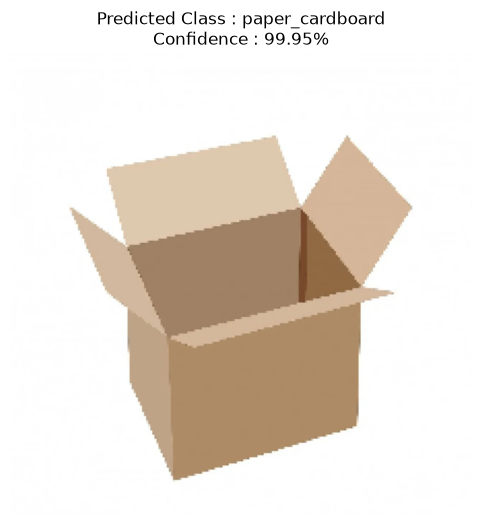

In [8]:
plt.figure(figsize=(6,6))
plt.imshow(SC_img)
plt.axis("off")

plt.title(
    f"Predicted Class : {SC_predicted_class}\n"
    f"Confidence : {SC_confidence:.2f}%"
)

plt.show()

In [9]:
print("Prediction Probabilities:\n")

for i, class_name in enumerate(SC_class_names):
    print(f"{class_name} : {SC_prediction[0][i]*100:.2f}%")

Prediction Probabilities:

battery : 0.00%
glass : 0.00%
metal : 0.00%
organic_waste : 0.03%
paper_cardboard : 99.95%
plastic : 0.01%
textiles : 0.00%
